## Data Import

In [1]:
import tensorflow as tf  # main deep learning library
tf.random.set_seed(42)  # fix seed for reproducibility across all runs

import numpy as np  # for arrays
np.random.seed(42)  # fix numpy's random seed too (used in oversampling, splits etc.)

import kagglehub  # to download kaggle dataset directly

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")  # download dataset

print("Dataset downloaded to:", path)  # shows extraction folder

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset downloaded to: /kaggle/input/gtsrb-german-traffic-sign


In [2]:
import pandas as pd  # to read CSV files
from PIL import Image  # to load and resize images
import os  # for file paths
import matplotlib.pyplot as plt  # for plotting
from tensorflow.keras import layers, models  # to build CNN layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # smart training
from tensorflow.keras.losses import CategoricalFocalCrossentropy  # focal loss
from tensorflow.keras.utils import to_categorical  # one-hot encoding
from sklearn.model_selection import train_test_split  # stratified splitting
from sklearn.metrics import classification_report, confusion_matrix  # evaluation
from sklearn.utils.class_weight import compute_class_weight  # for weighted loss
from collections import Counter  # for oversampling counts
import seaborn as sns  # for heatmaps

In [3]:
DATASET_DIR = path  # base folder from kagglehub download

train_df = pd.read_csv(os.path.join(DATASET_DIR, "Train.csv"))  # load training metadata

IMG_SIZE = 32  # resize target

images = []  # image arrays
labels = []  # class labels

for idx, row in train_df.iterrows():  # loop through Train.csv rows
    img_path = os.path.join(DATASET_DIR, row["Path"])  # full image path
    img = Image.open(img_path).convert("RGB")  # open and force RGB
    img = img.resize((IMG_SIZE, IMG_SIZE))  # resize
    images.append(np.array(img))  # store pixels
    labels.append(row["ClassId"])  # store label

X = np.array(images, dtype="float32") / 255.0  # normalize
y = np.array(labels)  # convert to array

print("X shape:", X.shape)  # sanity check
print("y shape:", y.shape)  # sanity check

X shape: (39209, 32, 32, 3)
y shape: (39209,)


In [4]:
test_df = pd.read_csv(os.path.join(DATASET_DIR, "Test.csv"))  # load test metadata

test_images = []  # test image arrays
test_labels = []  # test class labels

for idx, row in test_df.iterrows():  # loop through Test.csv rows
    img_path = os.path.join(DATASET_DIR, row["Path"])  # full test image path
    img = Image.open(img_path).convert("RGB")  # open and force RGB
    img = img.resize((IMG_SIZE, IMG_SIZE))  # resize
    test_images.append(np.array(img))  # store pixels
    test_labels.append(row["ClassId"])  # store true label

X_test = np.array(test_images, dtype="float32") / 255.0  # normalize
y_test = np.array(test_labels)  # convert to array

print("X_test shape:", X_test.shape)  # sanity check
print("y_test shape:", y_test.shape)  # sanity check

X_test shape: (12630, 32, 32, 3)
y_test shape: (12630,)


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,  # full training dataset
    test_size=0.2,  # 20% for validation
    stratify=y,  # keep class ratio same in both splits
    random_state=42  # fixed seed for reproducibility
)

print("X_train shape:", X_train.shape)  # check training set size
print("X_val shape:", X_val.shape)  # check validation set size

X_train shape: (31367, 32, 32, 3)
X_val shape: (7842, 32, 32, 3)


## Baseline Architecture


In [6]:
NUM_CLASSES = 43  # total number of traffic sign classes

y_train_cat = to_categorical(y_train, NUM_CLASSES)  # one-hot encode training labels
y_val_cat = to_categorical(y_val, NUM_CLASSES)  # one-hot encode validation labels
y_test_cat = to_categorical(y_test, NUM_CLASSES)  # one-hot encode test labels

In [7]:
def build_model():  # function so all 4 experiments use the exact same architecture
    model = models.Sequential([
        layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),  # block 1
        layers.BatchNormalization(),  # stabilize training
        layers.MaxPooling2D(),  # downsample

        layers.Conv2D(64, 3, padding='same', activation='relu'),  # block 2
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),  # block 3
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding='same', activation='relu'),  # block 4
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),  # replaces Flatten, fewer params

        layers.Dropout(0.4),  # regularization before final layer
        layers.Dense(NUM_CLASSES, activation='softmax')  # output layer
    ])
    return model  # return fresh, untrained model

In [8]:
tf.random.set_seed(42)  # reset seed right before building, so weight init is identical every time we call build_model()

baseline_model = build_model()  # create baseline architecture

baseline_model.compile(
    optimizer='adam',  # standard optimizer choice
    loss='categorical_crossentropy',  # plain loss, no imbalance handling
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',  # watch validation loss
    patience=5,  # stop if no improvement for 5 epochs
    restore_best_weights=True  # roll back to best epoch's weights
)

checkpoint = ModelCheckpoint(
    'baseline_model.keras',  # save file name
    monitor='val_loss',  # save based on best validation loss
    save_best_only=True  # only keep the best version
)

history_baseline = baseline_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,  # upper limit, early stopping will likely cut it shorter
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.7526 - loss: 0.9359 - val_accuracy: 0.6204 - val_loss: 1.3152
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9799 - loss: 0.0854 - val_accuracy: 0.9810 - val_loss: 0.0766
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9888 - loss: 0.0447 - val_accuracy: 0.9911 - val_loss: 0.0352
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9925 - loss: 0.0305 - val_accuracy: 0.9894 - val_loss: 0.0405
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9962 - loss: 0.0163 - val_accuracy: 0.9721 - val_loss: 0.0956
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9943 - loss: 0.0218 - val_accuracy: 0.9727 - val_loss: 0.0901
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9953 - loss: 0.0174 - val_accuracy: 0.9957 - val_loss: 0.0164
Epoch 8/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9944 - loss: 0.0210 - val_accuracy: 

Per Class Evaluation

In [9]:
y_pred_probs = baseline_model.predict(X_test)  # get predicted probabilities for test set
y_pred = np.argmax(y_pred_probs, axis=1)  # convert probabilities to class predictions

report = classification_report(y_test, y_pred, digits=3, output_dict=True)  # per-class precision/recall/f1
report_df = pd.DataFrame(report).transpose()  # convert to a readable table

print(classification_report(y_test, y_pred, digits=3))  # print full report to console

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

           0      1.000     0.950     0.974        60
           1      0.997     0.983     0.990       720
           2      0.967     0.991     0.979       750
           3      0.973     0.953     0.963       450
           4      0.976     0.980     0.978       660
           5      0.942     0.960     0.951       630
           6      0.982     0.713     0.826       150
           7      0.989     0.987     0.988       450
           8      0.974     0.984     0.979       450
           9      0.994     0.992     0.993       480
          10      0.985     0.983     0.984       660
          11      0.922     0.990     0.955       420
          12      0.934     0.997     0.964       690
          13      0.980     0.996     0.988       720
          14      0.968     1.000     0.984       270
          15      0.995     1.000     0.998       210
          16      0.968     1.000     0.

In [10]:
class_counts_train = Counter(y_train)  # count how many training images each class had

per_class_recall = report_df.loc[[str(i) for i in range(NUM_CLASSES)], 'recall']  # extract recall per class
per_class_count = [class_counts_train[i] for i in range(NUM_CLASSES)]  # matching training count per class

comparison_df = pd.DataFrame({
    'class': range(NUM_CLASSES),
    'train_count': per_class_count,
    'recall': per_class_recall.values
})  # sort mat karo yahan — order 0..42 rehne do taake baad ke columns sahi align hon

print(comparison_df.sort_values('train_count'))  # sirf print ke liye sort karo, dataframe ko nahi

    class  train_count    recall
0       0          168  0.950000
19     19          168  1.000000
37     37          168  0.983333
27     27          192  0.500000
41     41          192  0.950000
42     42          192  0.911111
32     32          192  1.000000
24     24          216  0.966667
29     29          216  1.000000
39     39          240  0.911111
21     21          264  0.655556
40     40          288  0.922222
20     20          288  0.988889
36     36          312  0.916667
22     22          312  0.858333
16     16          336  1.000000
34     34          336  1.000000
6       6          336  0.713333
30     30          360  0.620000
23     23          408  0.940000
28     28          432  0.973333
26     26          480  0.983333
15     15          504  1.000000
33     33          551  0.995238
31     31          624  0.966667
14     14          624  1.000000
17     17          888  0.969444
18     18          960  0.858974
35     35          960  0.971795
11     11 

In [11]:
cm = confusion_matrix(y_test, y_pred)  # full confusion matrix, all 43 classes

# check what class 27 gets confused with
class_id = 27  # pedestrians, worst performer
confusions = cm[class_id]  # row for this class = true label, columns = predicted
top_confusions = np.argsort(confusions)[::-1][:5]  # top 5 predicted classes (including correct one)
print(f"Class {class_id} confused with:")  # header
for c in top_confusions:  # loop through top confused classes
    if confusions[c] > 0:  # only show non-zero confusions
        print(f"  predicted as class {c}: {confusions[c]} times")  # show count

# same check for class 21 (double curve)
class_id = 21  # double curve
confusions = cm[class_id]  # row for this class
top_confusions = np.argsort(confusions)[::-1][:5]  # top 5 confused classes
print(f"\nClass {class_id} confused with:")  # header
for c in top_confusions:
    if confusions[c] > 0:
        print(f"  predicted as class {c}: {confusions[c]} times")

Class 27 confused with:
  predicted as class 27: 30 times
  predicted as class 12: 13 times
  predicted as class 11: 11 times
  predicted as class 14: 5 times
  predicted as class 3: 1 times

Class 21 confused with:
  predicted as class 21: 59 times
  predicted as class 12: 10 times
  predicted as class 10: 8 times
  predicted as class 5: 6 times
  predicted as class 13: 5 times


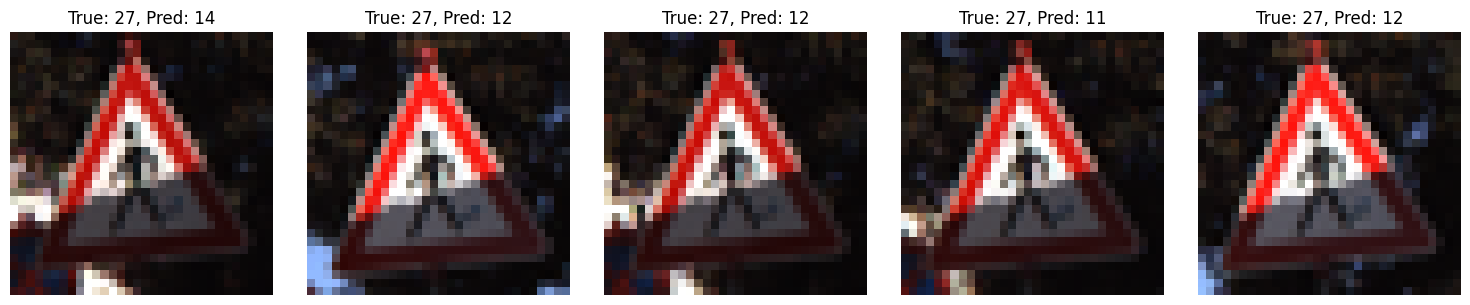

In [12]:
misclassified_idx = np.where((y_test == 27) & (y_pred != 27))[0]  # find indices where true label is 27 but predicted wrong

fig, axes = plt.subplots(1, 5, figsize=(15, 3))  # show first 5 misclassified examples
for i, idx in enumerate(misclassified_idx[:5]):  # loop through first 5
    axes[i].imshow(X_test[idx])  # show the actual image
    axes[i].set_title(f"True: 27, Pred: {y_pred[idx]}")  # show true vs predicted label
    axes[i].axis('off')  # hide axis for cleaner look
plt.tight_layout()  # fix spacing
plt.savefig("class27_misclassified.png")  # save figure
plt.show()  # display

Manual inspection of misclassified samples confirmed that many errors stem from low image resolution (32x32) rather than a single dominant confusion pattern, suggesting the network struggles to extract distinguishing features from certain classes regardless of shape/color category

## Weighted model

In [13]:
class_weights_array = compute_class_weight(
    class_weight='balanced',  # inverse-frequency weighting
    classes=np.unique(y_train),  # all class ids present in training set
    y=y_train  # training labels (before one-hot)
)  # compute weight per class

class_weights = dict(enumerate(class_weights_array))  # convert to dict format Keras expects: {0: weight, 1: weight, ...}

print(class_weights)  # sanity check — rare classes should have higher weight

{0: np.float64(4.342054263565892), 1: np.float64(0.41073486276974647), 2: np.float64(0.40525839793281654), 3: np.float64(0.6466889328715157), 4: np.float64(0.460520906741837), 5: np.float64(0.4902319329832458), 6: np.float64(2.171027131782946), 7: np.float64(0.6332162467700259), 8: np.float64(0.6466889328715157), 9: np.float64(0.6202934662236987), 10: np.float64(0.4536474603725558), 11: np.float64(0.6907813601127555), 12: np.float64(0.43420542635658915), 13: np.float64(0.4221441645133506), 14: np.float64(1.169014609421586), 15: np.float64(1.4473514211886305), 16: np.float64(2.171027131782946), 17: np.float64(0.8214697255394929), 18: np.float64(0.759859496124031), 19: np.float64(4.342054263565892), 20: np.float64(2.5328649870801034), 21: np.float64(2.763125440451022), 22: np.float64(2.338029218843172), 23: np.float64(1.787904696762426), 24: np.float64(3.3771533161068046), 25: np.float64(0.6078875968992248), 26: np.float64(1.519718992248062), 27: np.float64(3.799297480620155), 28: np.flo

In [14]:
tf.random.set_seed(42)  # reset seed so weight init matches baseline exactly

weighted_model = build_model()  # same architecture as baseline

weighted_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # same loss function...
    metrics=['accuracy']
)  # ...but class_weight will be passed during fit, not here

early_stop_w = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)  # same early stopping config as baseline

checkpoint_w = ModelCheckpoint(
    'weighted_model.keras',  # different filename so it doesn't overwrite baseline
    monitor='val_loss',
    save_best_only=True
)

history_weighted = weighted_model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,  # <-- ye hi is model ka sirf difference hai baseline se
    callbacks=[early_stop_w, checkpoint_w]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.6558 - loss: 1.1613 - val_accuracy: 0.4169 - val_loss: 3.0617
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9644 - loss: 0.1115 - val_accuracy: 0.9387 - val_loss: 0.2386
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9883 - loss: 0.0357 - val_accuracy: 0.9740 - val_loss: 0.0881
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9814 - loss: 0.0575 - val_accuracy: 0.9852 - val_loss: 0.0529
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9882 - loss: 0.0346 - val_accuracy: 0.5645 - val_loss: 1.9012
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9880 - loss: 0.0381 - val_accuracy: 0.9962 - val_loss: 0.0157
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9986 - loss: 0.0052 - val_accuracy: 0.9969 - val_loss: 0.0099
Epoch 8/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9992 - loss: 0.0034 - val_accuracy: 

In [15]:
y_pred_probs_w = weighted_model.predict(X_test)  # predicted probabilities, weighted model
y_pred_w = np.argmax(y_pred_probs_w, axis=1)  # convert to class predictions

report_w = classification_report(y_test, y_pred_w, digits=3, output_dict=True)  # per-class metrics
report_df_w = pd.DataFrame(report_w).transpose()  # convert to dataframe

print(classification_report(y_test, y_pred_w, digits=3))  # print full report

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0      1.000     0.933     0.966        60
           1      0.979     0.990     0.985       720
           2      0.966     0.989     0.978       750
           3      0.941     0.964     0.953       450
           4      0.987     0.950     0.968       660
           5      0.939     0.976     0.957       630
           6      0.936     0.880     0.907       150
           7      0.993     0.951     0.972       450
           8      0.957     0.980     0.968       450
           9      0.985     0.990     0.988       480
          10      0.994     0.983     0.989       660
          11      0.962     0.964     0.963       420
          12      0.994     0.990     0.992       690
          13      0.993     0.997     0.995       720
          14      0.993     1.000     0.996       270
          15      0.986     0.986     0.986       210
          16      1.000     1.000     1.

In [16]:
per_class_recall_w = report_df_w.loc[[str(i) for i in range(NUM_CLASSES)], 'recall']  # extract recall per class, weighted model

comparison_df['recall_weighted'] = per_class_recall_w.values  # add weighted recall as new column to existing comparison table
comparison_df['recall_change'] = comparison_df['recall_weighted'] - comparison_df['recall']  # how much recall changed vs baseline

print(comparison_df.sort_values('train_count'))  # show table, rarest classes first, with both recalls + change

    class  train_count    recall  recall_weighted  recall_change
0       0          168  0.950000         0.933333      -0.016667
19     19          168  1.000000         0.983333      -0.016667
37     37          168  0.983333         0.983333       0.000000
27     27          192  0.500000         0.500000       0.000000
41     41          192  0.950000         0.866667      -0.083333
42     42          192  0.911111         0.911111       0.000000
32     32          192  1.000000         1.000000       0.000000
24     24          216  0.966667         0.955556      -0.011111
29     29          216  1.000000         1.000000       0.000000
39     39          240  0.911111         0.833333      -0.077778
21     21          264  0.655556         0.655556       0.000000
40     40          288  0.922222         0.811111      -0.111111
20     20          288  0.988889         1.000000       0.011111
36     36          312  0.916667         0.966667       0.050000
22     22          312  0

## Oversampled Model

In [17]:
from collections import Counter  # already imported, just confirming usage here

class_counts_dict = Counter(y_train)  # count of images per class in training set
max_count = max(class_counts_dict.values())  # target count = size of largest class

oversampled_indices = []  # will hold final list of indices (with duplicates for rare classes)

for class_id in range(NUM_CLASSES):  # loop through every class
    class_indices = np.where(y_train == class_id)[0]  # indices of all images belonging to this class
    num_needed = max_count  # we want this class to reach the max class size
    sampled = np.random.choice(class_indices, size=num_needed, replace=True)  # sample with replacement until balanced
    oversampled_indices.extend(sampled)  # add to master list

oversampled_indices = np.array(oversampled_indices)  # convert to numpy array
np.random.shuffle(oversampled_indices)  # shuffle so batches are mixed, not grouped by class

X_train_over = X_train[oversampled_indices]  # build oversampled training images
y_train_over = y_train[oversampled_indices]  # build oversampled training labels

print("Original X_train shape:", X_train.shape)  # sanity check, before oversampling
print("Oversampled X_train shape:", X_train_over.shape)  # sanity check, after oversampling
print("New class distribution:", Counter(y_train_over))  # confirm all classes now roughly equal

Original X_train shape: (31367, 32, 32, 3)
Oversampled X_train shape: (77400, 32, 32, 3)
New class distribution: Counter({np.int64(28): 1800, np.int64(38): 1800, np.int64(6): 1800, np.int64(0): 1800, np.int64(19): 1800, np.int64(9): 1800, np.int64(10): 1800, np.int64(33): 1800, np.int64(26): 1800, np.int64(22): 1800, np.int64(14): 1800, np.int64(15): 1800, np.int64(39): 1800, np.int64(37): 1800, np.int64(16): 1800, np.int64(4): 1800, np.int64(13): 1800, np.int64(31): 1800, np.int64(25): 1800, np.int64(40): 1800, np.int64(17): 1800, np.int64(12): 1800, np.int64(27): 1800, np.int64(41): 1800, np.int64(21): 1800, np.int64(2): 1800, np.int64(24): 1800, np.int64(11): 1800, np.int64(20): 1800, np.int64(5): 1800, np.int64(29): 1800, np.int64(42): 1800, np.int64(18): 1800, np.int64(32): 1800, np.int64(1): 1800, np.int64(35): 1800, np.int64(36): 1800, np.int64(3): 1800, np.int64(23): 1800, np.int64(8): 1800, np.int64(30): 1800, np.int64(7): 1800, np.int64(34): 1800})


In [18]:
y_train_over_cat = to_categorical(y_train_over, NUM_CLASSES)  # one-hot encode oversampled labels

In [19]:
tf.random.set_seed(42)  # reset seed so weight init matches baseline exactly

oversampled_model = build_model()  # same architecture as baseline

oversampled_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",  # plain loss, no weighting needed here — balance comes from the data itself
    metrics=["accuracy"]
)

early_stop_o = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_o = ModelCheckpoint(
    "oversampled_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history_oversampled = oversampled_model.fit(
    X_train_over, y_train_over_cat,  # oversampled data used here, note: still same X_val for fair comparison
    validation_data=(X_val, y_val_cat),  # validation set stays untouched — never oversample validation/test data
    epochs=30,
    batch_size=64,
    callbacks=[early_stop_o, checkpoint_o]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8896 - loss: 0.4250 - val_accuracy: 0.9662 - val_loss: 0.1157
Epoch 2/30
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9924 - loss: 0.0302 - val_accuracy: 0.9778 - val_loss: 0.0732
Epoch 3/30
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9950 - loss: 0.0185 - val_accuracy: 0.9700 - val_loss: 0.1060
Epoch 4/30
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9957 - loss: 0.0162 - val_accuracy: 0.9865 - val_loss: 0.0551
Epoch 5/30
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9971 - loss: 0.0105 - val_accuracy: 0.9841 - val_loss: 0.0616
Epoch 6/30
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9963 - loss: 0.0136 - val_accuracy: 0.9927 - val_loss: 0.0239
Epoch 7/30
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9978 - loss: 0.0078 - val_accuracy: 0.9874 - val_loss: 0.0432
Epoch 8/30
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9980 - loss: 0.0073 

In [20]:
y_pred_probs_o = oversampled_model.predict(X_test)  # predicted probabilities, oversampled model
y_pred_o = np.argmax(y_pred_probs_o, axis=1)  # convert to class predictions

report_o = classification_report(y_test, y_pred_o, digits=3, output_dict=True)  # per-class metrics
report_df_o = pd.DataFrame(report_o).transpose()  # convert to dataframe

print(classification_report(y_test, y_pred_o, digits=3))  # print full report

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0      0.894     0.983     0.937        60
           1      0.986     0.994     0.990       720
           2      0.989     0.987     0.988       750
           3      0.973     0.967     0.970       450
           4      0.992     0.986     0.989       660
           5      0.947     0.987     0.967       630
           6      1.000     0.780     0.876       150
           7      0.989     0.984     0.987       450
           8      0.978     0.980     0.979       450
           9      0.996     1.000     0.998       480
          10      0.998     0.985     0.992       660
          11      0.963     0.981     0.972       420
          12      0.991     0.972     0.982       690
          13      0.960     0.997     0.978       720
          14      0.989     1.000     0.994       270
          15      0.968     0.995     0.981       210
          16      0.974     1.000     0.

In [21]:
per_class_recall_o = report_df_o.loc[[str(i) for i in range(NUM_CLASSES)], "recall"]  # extract recall per class, oversampled model

comparison_df["recall_oversampled"] = per_class_recall_o.values  # add oversampled recall as new column
comparison_df["recall_change_oversampled"] = comparison_df["recall_oversampled"] - comparison_df["recall"]  # change vs baseline recall

print(comparison_df.sort_values("train_count"))  # show table, rarest classes first

    class  train_count    recall  recall_weighted  recall_change  \
0       0          168  0.950000         0.933333      -0.016667   
19     19          168  1.000000         0.983333      -0.016667   
37     37          168  0.983333         0.983333       0.000000   
27     27          192  0.500000         0.500000       0.000000   
41     41          192  0.950000         0.866667      -0.083333   
42     42          192  0.911111         0.911111       0.000000   
32     32          192  1.000000         1.000000       0.000000   
24     24          216  0.966667         0.955556      -0.011111   
29     29          216  1.000000         1.000000       0.000000   
39     39          240  0.911111         0.833333      -0.077778   
21     21          264  0.655556         0.655556       0.000000   
40     40          288  0.922222         0.811111      -0.111111   
20     20          288  0.988889         1.000000       0.011111   
36     36          312  0.916667         0.96666

In [22]:
cm_o = confusion_matrix(y_test, y_pred_o)  # confusion matrix for oversampled model

class_id = 18  # general caution, now catastrophically dropped
confusions = cm_o[class_id]  # row for this class
top_confusions = np.argsort(confusions)[::-1][:5]  # top 5 predicted classes
print(f"Class {class_id} confused with (oversampled model):")
for c in top_confusions:
    if confusions[c] > 0:
        print(f"  predicted as class {c}: {confusions[c]} times")

Class 18 confused with (oversampled model):
  predicted as class 18: 345 times
  predicted as class 27: 8 times
  predicted as class 11: 8 times
  predicted as class 26: 6 times
  predicted as class 13: 6 times


In [23]:
print("Baseline macro-F1:", report_df.loc["macro avg", "f1-score"])  # baseline model's macro-F1
print("Weighted macro-F1:", report_df_w.loc["macro avg", "f1-score"])  # weighted model's macro-F1
print("Oversampled macro-F1:", report_df_o.loc["macro avg", "f1-score"])  # oversampled model's macro-F1

Baseline macro-F1: 0.9362751075847204
Weighted macro-F1: 0.9380795137182417
Oversampled macro-F1: 0.9523527155958866


## Focal Loss Model

In [24]:
tf.random.set_seed(42)  # reset seed so weight init matches baseline exactly

focal_model = build_model()  # same architecture as baseline

focal_model.compile(
    optimizer="adam",
    loss=CategoricalFocalCrossentropy(gamma=2.0),  # focal loss, gamma controls focus on hard examples
    metrics=["accuracy"]
)

early_stop_f = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_f = ModelCheckpoint(
    "focal_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history_focal = focal_model.fit(
    X_train, y_train_cat,  # original (non-oversampled) training data — focal loss handles imbalance via the loss function itself
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop_f, checkpoint_f]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7507 - loss: 0.1807 - val_accuracy: 0.5488 - val_loss: 0.3307
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9665 - loss: 0.0152 - val_accuracy: 0.9649 - val_loss: 0.0153
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9843 - loss: 0.0066 - val_accuracy: 0.9848 - val_loss: 0.0067
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9890 - loss: 0.0040 - val_accuracy: 0.9462 - val_loss: 0.0219
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9903 - loss: 0.0035 - val_accuracy: 0.9600 - val_loss: 0.0194
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9907 - loss: 0.0034 - val_accuracy: 0.9902 - val_loss: 0.0037
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9931 - loss: 0.0025 - val_accuracy: 0.9811 - val_loss: 0.0078
Epoch 8/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9909 - loss: 0.0033 - val_accuracy: 

In [25]:
y_pred_probs_f = focal_model.predict(X_test)  # predicted probabilities, focal model
y_pred_f = np.argmax(y_pred_probs_f, axis=1)  # convert to class predictions

report_f = classification_report(y_test, y_pred_f, digits=3, output_dict=True)  # per-class metrics
report_df_f = pd.DataFrame(report_f).transpose()  # convert to dataframe

print(classification_report(y_test, y_pred_f, digits=3))  # print full report

395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
              precision    recall  f1-score   support

           0      1.000     0.883     0.938        60
           1      0.970     0.989     0.979       720
           2      0.989     0.996     0.993       750
           3      0.982     0.949     0.965       450
           4      0.989     0.968     0.979       660
           5      0.868     0.994     0.927       630
           6      1.000     0.920     0.958       150
           7      0.985     0.887     0.933       450
           8      0.971     0.973     0.972       450
           9      0.971     0.973     0.972       480
          10      0.972     0.982     0.977       660
          11      0.848     1.000     0.918       420
          12      0.969     0.958     0.964       690
          13      0.986     0.996     0.991       720
          14      0.978     0.996     0.987       270
          15      0.945     0.986     0.965       210
          16      1.000     1.000     1.

In [26]:
per_class_recall_f = report_df_f.loc[[str(i) for i in range(NUM_CLASSES)], "recall"]  # extract recall per class, focal model, natural class order

comparison_df["recall_focal"] = per_class_recall_f.values  # safe: comparison_df is still in class-id order (0..42), so positional assignment aligns correctly
comparison_df["recall_change_focal"] = comparison_df["recall_focal"] - comparison_df["recall"]  # change vs baseline

print(comparison_df.sort_values("train_count"))  # sort only for display

    class  train_count    recall  recall_weighted  recall_change  \
0       0          168  0.950000         0.933333      -0.016667   
19     19          168  1.000000         0.983333      -0.016667   
37     37          168  0.983333         0.983333       0.000000   
27     27          192  0.500000         0.500000       0.000000   
41     41          192  0.950000         0.866667      -0.083333   
42     42          192  0.911111         0.911111       0.000000   
32     32          192  1.000000         1.000000       0.000000   
24     24          216  0.966667         0.955556      -0.011111   
29     29          216  1.000000         1.000000       0.000000   
39     39          240  0.911111         0.833333      -0.077778   
21     21          264  0.655556         0.655556       0.000000   
40     40          288  0.922222         0.811111      -0.111111   
20     20          288  0.988889         1.000000       0.011111   
36     36          312  0.916667         0.96666

In [27]:
print("Focal macro-F1:", report_df_f.loc["macro avg", "f1-score"])  # focal model's macro-F1, for the summary comparison table

Focal macro-F1: 0.9210978235933


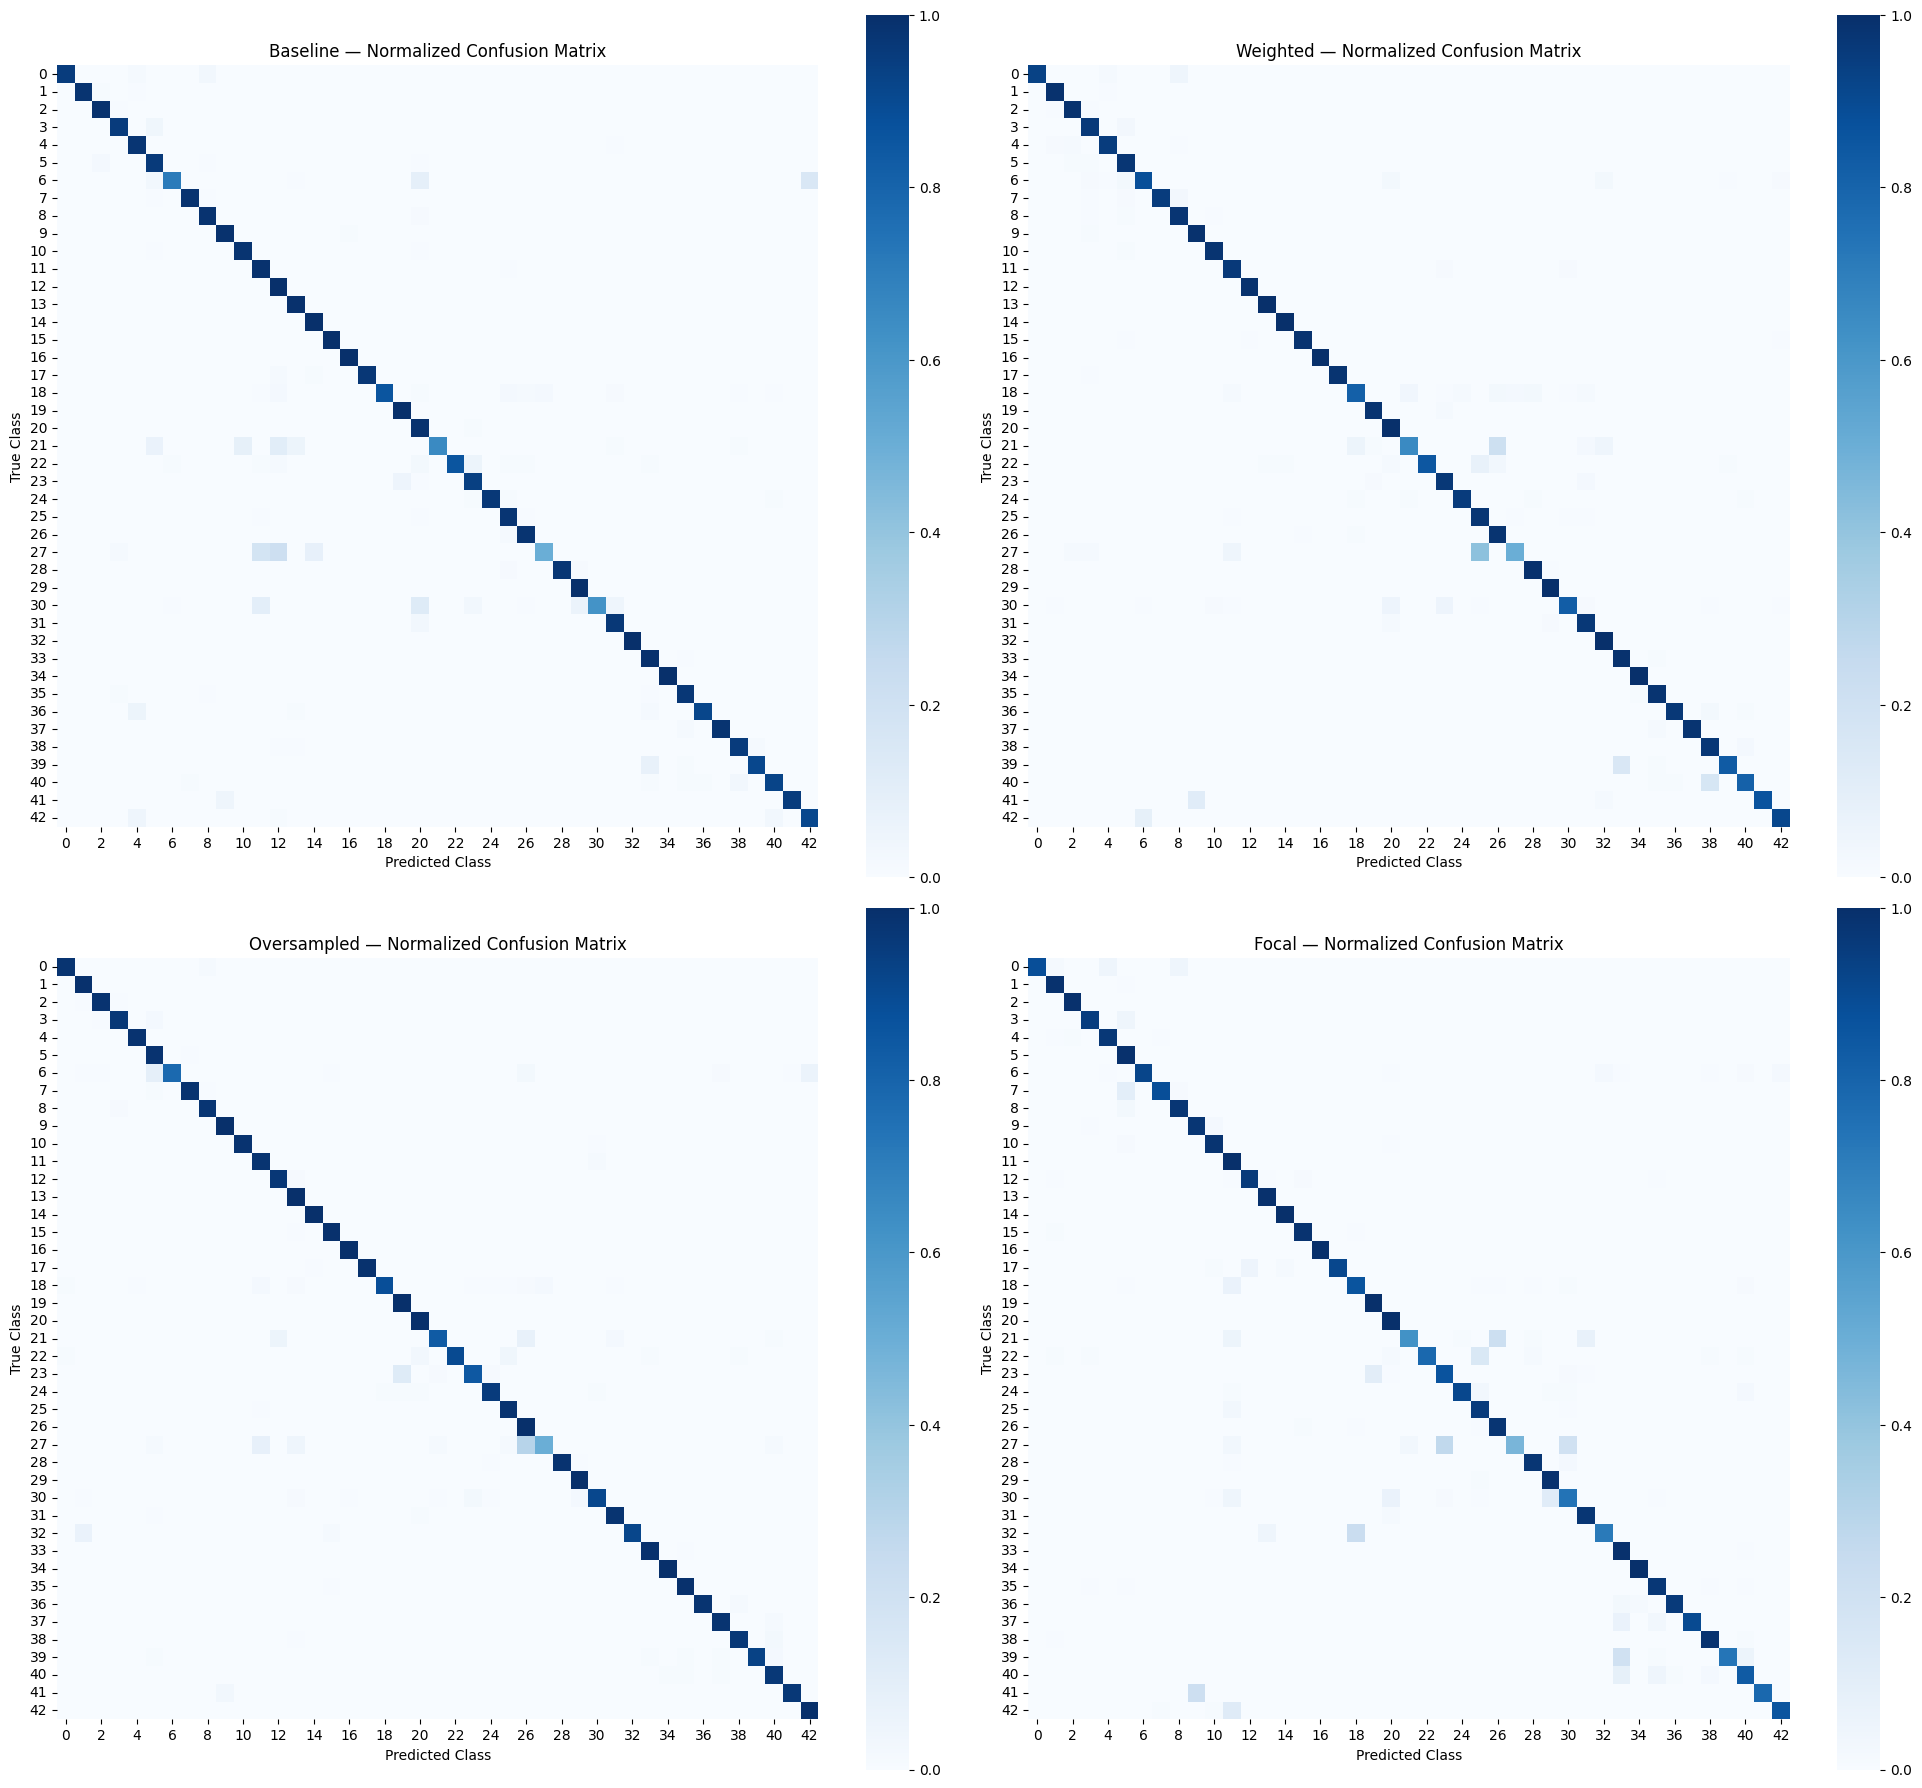

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(20, 18))  # 2x2 grid for 4 models

models_data = [
    ("Baseline", y_pred),        # baseline predictions
    ("Weighted", y_pred_w),      # weighted model predictions
    ("Oversampled", y_pred_o),   # oversampled model predictions
    ("Focal", y_pred_f)          # focal model predictions
]

for ax, (name, preds) in zip(axes.flat, models_data):  # loop through each model and its subplot
    cm = confusion_matrix(y_test, preds)  # compute confusion matrix for this model
    cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)  # normalize by true class count (row-wise), so each row sums to 1
    sns.heatmap(cm_normalized, ax=ax, cmap="Blues", cbar=True, square=True)  # draw heatmap, no annotations (43x43 too dense for numbers)
    ax.set_title(f"{name} — Normalized Confusion Matrix")  # title per subplot
    ax.set_xlabel("Predicted Class")  # x-axis label
    ax.set_ylabel("True Class")  # y-axis label

plt.tight_layout()  # fix spacing between subplots
plt.savefig("all_models_confusion_matrices.png", dpi=150)  # save high-res for report
plt.show()  # display